In [1]:
import pandas as pd
import numpy as np
from os import getcwd, listdir, path
import matplotlib.pyplot as plt
import sys
import ast
from glob import glob

import fitness.data_generating_process as dgp
import fitness.soga_fitness_SCM as soga_fitness_SCM
import fitness.interventions as interventions

In [2]:
# Read all pareto_fitness.txt files under results/causal_skills_tests and build aggregated stats
ex_name = 'complex'
program = 'complex'
base_dir = path.join('..', 'results', ex_name)
pattern = path.join(base_dir, '**', 'stats.tsv')

# Read ONLY the column best_fitness from all stats.tsv files, change the value tensor(-1000000.) to -1000000.0, and FOR EACH ROW compute mean, std, median and interquartile ranges (25, 75)
# and save the results in a new dataframe with columns: mean, std, median, q25, q75.Do not consider interventions.

files = glob(pattern, recursive=True)
dfs = []
for file in files:
    df = pd.read_csv(file, sep='\t')
    df['best_fitness'] = df['best_fitness'].replace('tensor(-1000000.)', -1000000.0).astype(float)
    dfs.append(df[['best_fitness']])

# for each row, compute mean, std, median, q25 and q75
results = []
for i in range(len(dfs[0])):
    values = [df['best_fitness'].iloc[i] for df in dfs]
    mean = np.mean(values)
    std = np.std(values)
    median = np.median(values)
    q25 = np.percentile(values, 25)
    q75 = np.percentile(values, 75)
    results.append({'mean': mean, 'std': std, 'median': median, 'q25': q25, 'q75': q75})

results_df = pd.DataFrame(results)
print(results_df)


               mean  std          median             q25             q75
0   -1000000.000000  0.0 -1000000.000000 -1000000.000000 -1000000.000000
1   -1000000.000000  0.0 -1000000.000000 -1000000.000000 -1000000.000000
2   -1000000.000000  0.0 -1000000.000000 -1000000.000000 -1000000.000000
3   -1000000.000000  0.0 -1000000.000000 -1000000.000000 -1000000.000000
4   -1000000.000000  0.0 -1000000.000000 -1000000.000000 -1000000.000000
..              ...  ...             ...             ...             ...
296     -183.627017  0.0     -183.627017     -183.627017     -183.627017
297     -183.627017  0.0     -183.627017     -183.627017     -183.627017
298     -183.627017  0.0     -183.627017     -183.627017     -183.627017
299     -183.627017  0.0     -183.627017     -183.627017     -183.627017
300     -183.627017  0.0     -183.627017     -183.627017     -183.627017

[301 rows x 5 columns]


In [3]:
vars, scm = dgp.get_vars(program)
real_program = dgp.get_real_program(program)
baseline_program = dgp.get_baseline_program(program)
real_dataset = dgp.generate_interventional_dataset(scm, vars, 1000)

likelihood = soga_fitness_SCM.compute_likelihood(real_program, vars, real_dataset)
likelihood_base = soga_fitness_SCM.compute_likelihood(baseline_program, vars, real_dataset)
interventions_list = dgp.get_intervention_list(program)
for var, value in interventions_list:
    dataset_file = f'fitness/datasets/{program}_intervention_{var}_{value}.csv'
    data_intervened = np.loadtxt(dataset_file, delimiter=',')
    program_intervened = interventions.apply_intervention_to_program(real_program, var, value)
    baseline_program_intervened = interventions.apply_intervention_to_program(baseline_program, var, value)
    interventional_likelihood = soga_fitness_SCM.compute_likelihood(program_intervened, vars, data_intervened)
    interventional_likelihood_base = soga_fitness_SCM.compute_likelihood(baseline_program_intervened, vars, data_intervened)
    likelihood += interventional_likelihood
    likelihood_base += interventional_likelihood_base


print(f'Total likelihood of real program: {likelihood}')
print(f'Total likelihood of baseline program: {likelihood_base}')


Total likelihood of real program: -99.30401998484236
Total likelihood of baseline program: -153.54027896169765


In [4]:
# between all the files, find the one with best likelihood and print the corresponding program
best_likelihood = -np.inf
best_program = None
for file in files:
    df = pd.read_csv(file, sep='\t')
    df['best_fitness'] = df['best_fitness'].replace('tensor(-1000000.)', -1000000.0).astype(float)
    max_likelihood = df['best_fitness'].max()
    if max_likelihood > best_likelihood:
        best_likelihood = max_likelihood
        best_program = file 
print(f'Best likelihood: {best_likelihood}')
#print(f'Best program file: {best_program}')

#in the folder where the best stats.tsv file is, print the content of the best.txt file
best_program_file = best_program.replace('stats.tsv', 'best.txt')
with open(best_program_file, 'r') as f:
    best_program_content = f.read()
print(f'Best program content:\n{best_program_content}')

Best likelihood: -183.62701663692053
Best program content:
Generation:
300

Phenotype:
2
V1 = gm([2.57e-0, +7.12e-0, 4.01e+0]);
V2 = +2.36e-3 * -V1 * -V1;
V2 = V2 + gm([0.86e+0, +4.62e+2, 0.30e+3], [2.57e-0, +7.12e-0, 4.01e+0]);
V3 = +2.36e-3 * -V2 * -V1;
V3 = V3 + gm([0.86e+0, +4.62e+2, 0.30e+3], [2.57e-0, +7.12e-0, 4.01e+0]);
V4 = +2.36e-3 * -V1 * -V1;
V4 = V4 + gm([0.86e+0, +4.62e+2, 0.30e+3], [2.57e-0, +7.12e-0, 4.01e+0]);
V5 = +2.36e-3 * -V4 * -V1;
V5 = V5 + gm([0.86e+0, +4.62e+2, 0.30e+3], [2.57e-0, +7.12e-0, 4.01e+0]);

Pre-processed Program
:F = gm([1.000000], [7.12], [4.01]);TEMP0 = 0.0024 * F;TEMP0 = TEMP0 * F;C = TEMP0;C = C + gm([0.250729, 0.749271], [462, 7.12], [300, 4.01]);TEMP1 = 0.0024 * C;TEMP1 = TEMP1 * F;W = TEMP1;W = W + gm([0.250729, 0.749271], [462, 7.12], [300, 4.01]);TEMP2 = 0.0024 * F;TEMP2 = TEMP2 * F;P = TEMP2;P = P + gm([0.250729, 0.749271], [462, 7.12], [300, 4.01]);TEMP3 = 0.0024 * P;TEMP3 = TEMP3 * F;T = TEMP3;T = T + gm([0.250729, 0.749271], [462, 7.12]

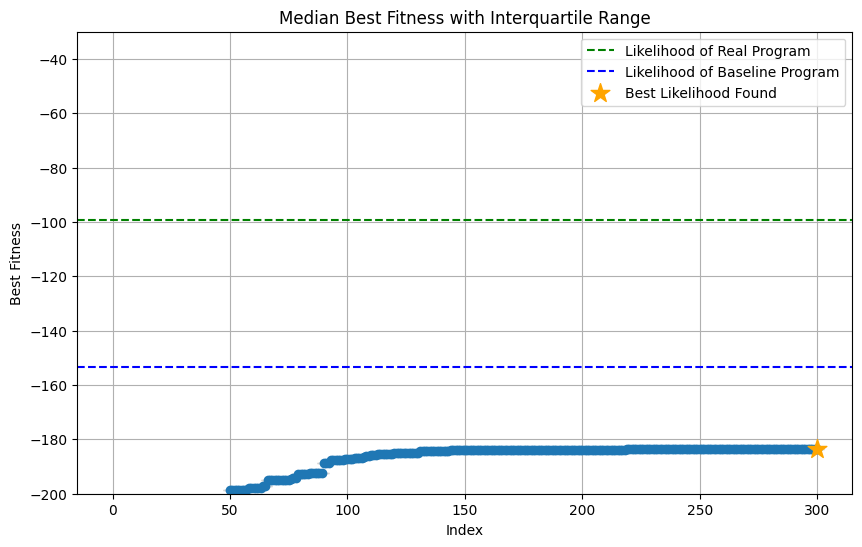

In [6]:
# Plot results_df median with error bars for q25 and q75
plt.figure(figsize=(10, 6))
plt.errorbar(results_df.index, results_df['median'], yerr=[results_df['median'] - results_df['q25'], results_df['q75'] - results_df['median']], fmt='o', ecolor='lightgray', capsize=5)
plt.title('Median Best Fitness with Interquartile Range')
plt.xlabel('Index')
plt.ylabel('Best Fitness')
plt.ylim(-200, -30)

# Add a horizontal line for the likelihood of the real program and the baseline program
plt.axhline(y=likelihood, color='g', linestyle='--', label='Likelihood of Real Program')
plt.axhline(y=likelihood_base, color='b', linestyle='--', label='Likelihood of Baseline Program')

# Add a point for the best likelihood found in the files with the shape of a star and color orange
plt.scatter(len(results_df)-1, best_likelihood, color='orange', label='Best Likelihood Found', zorder=5, marker='*', s=200)

plt.legend()

plt.grid()
plt.show()